# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Hisyam A.
- **Email:** athaya.hisyam.milis@gmail.com
- **ID Dicoding:** hathaya## 1. Deskripsi Dataset & Latar Belakang

Dataset ini berisi data kualitas udara jam-jaman dari **12 stasiun pemantau utama di Kota Beijing, Tiongkok**, yang dikumpulkan sepanjang periode **1 Maret 2013 hingga 28 Februari 2017**. Data meteorologi yang menyertainya diambil dari Stasiun Meteorologi Beijing milik *China Meteorological Administration*.

## Struktur dan Isi Parameter Dataset:
- **Informasi Observasi:** `No` (indeks), `year`, `month`, `day`, `hour`, serta `station` (nama stasiun pemantau).
- **Polutan Udara Utama:**
  - `PM2.5` & `PM10`: Partikel halus berukuran < 2.5 µg/m³ dan < 10 µg/m³.
  - `SO2`: Sulfur Dioksida.
  - `NO2`: Nitrogen Dioksida.
  - `CO`: Karbon Monoksida.
  - `O3`: Ozon.
- **Parameter Meteorologi (Cuaca):**
  - `TEMP`: Suhu udara (°C).
  - `PRES`: Tekanan udara (hPa).
  - `DEWP`: Titik embun / Dew Point (°C).
  - `RAIN`: Curah hujan (mm).
  - `wd`: Arah angin (*wind direction*).
  - `WSPM`: Kecepatan angin (*wind speed*, m/s).

**Sumber Data:** Repositori GitHub [HTI (marceloreis/HTI)](https://github.com/marceloreis/HTI) berlisensi GPL 3.0.



## Menentukan Pertanyaan Bisnis

Untuk eksplorasi dataset ini, disusunlah dua pertanyaan eksplorasi:

Q1: "Bagaimana tren konsentrasi rata-rata polutan PM2.5 di seluruh stasiun kota Beijing secara bulanan sepanjang periode Maret 2013 hingga Februari 2017?" (Tren Waktu)

Q2: "Bagaimana hubungan/korelasi antara faktor cuaca (suhu TEMP dan kecepatan angin WSPM) terhadap tingkat konsentrasi PM2.5 pada stasiun pemantau dengan tingkat polusi tertinggi secara bulanan sepanjang periode Maret 2013 hingga Februari 2027?" (Korelasi Cuaca)

## Package import

In [1]:
# Import library
# Analisis Data
import pandas as pd
import numpy as np

# Pengolahan File & Sistem
import glob
import os

# Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling
### Kloning Data Github

In [2]:
# Clone repositori Github dataset ke environment Colab
!git clone https://github.com/marceloreis/HTI.git

# Simpan path seluruh file CSV
path = './HTI/PRSA_Data_20130301-20170228'
all_files = glob.glob(os.path.join(path, "*.csv"))

Cloning into 'HTI'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 35 (delta 11), reused 24 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 10.22 MiB | 8.43 MiB/s, done.
Resolving deltas: 100% (11/11), done.


**Insight**

Agar data dapat didapat (retrieve) dengan lebih sederhana di setiap mesin, kode ini diterapkan untuk mengunduh langsung dataset dari repositori Github.

### Pemeriksaan dan penggabungan data


In [3]:
# Periksa shape() dari tiap csv files untuk memastikan tidak ada perbedaan jumlah kolom
for filename in all_files:
    df_temp = pd.read_csv(filename)
    print(f"File: {os.path.basename(filename)} | Shape: {df_temp.shape}")

File: PRSA_Data_Nongzhanguan_20130301-20170228.csv | Shape: (35064, 18)
File: PRSA_Data_Dingling_20130301-20170228.csv | Shape: (35064, 18)
File: PRSA_Data_Huairou_20130301-20170228.csv | Shape: (35064, 18)
File: PRSA_Data_Changping_20130301-20170228.csv | Shape: (35064, 18)
File: PRSA_Data_Guanyuan_20130301-20170228.csv | Shape: (35064, 18)
File: PRSA_Data_Dongsi_20130301-20170228.csv | Shape: (35064, 18)
File: PRSA_Data_Shunyi_20130301-20170228.csv | Shape: (35064, 18)
File: PRSA_Data_Wanshouxigong_20130301-20170228.csv | Shape: (35064, 18)
File: PRSA_Data_Aotizhongxin_20130301-20170228.csv | Shape: (35064, 18)
File: PRSA_Data_Gucheng_20130301-20170228.csv | Shape: (35064, 18)
File: PRSA_Data_Wanliu_20130301-20170228.csv | Shape: (35064, 18)
File: PRSA_Data_Tiantan_20130301-20170228.csv | Shape: (35064, 18)


**Insight**

Terdapat data dari 12 stasiun, yang tersimpan di 12 dataset berformat CSV. Terlihat dari hasil `shape()` bahwa setiap dataset memiliki jumlah baris dan kolom yang sama. Ini memungkinkan proses merging terjadi dengan lebih mudah.

In [4]:
# Gabungkan seluruh 12 file CSV menjadi satu DataFrame
df_list = []
for filename in all_files:
    data = pd.read_csv(filename)
    df_list.append(data)

# Satukan semua data secara vertikal
main_df = pd.concat(df_list, axis=0, ignore_index=True)

# main_df head
print(f"Total baris dan kolom: {main_df.shape}")
main_df.head()

Total baris dan kolom: (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan


**Insight**

Karena dataset terdiri dari 12 csv terpisah, dilakukan pemeriksaan `shape()` untuk setiap csv.

Karena tidak ada perbedaan jumlah kolom, dilakukan penggabungan ke dalam satu variabel `main_df`.

### Asesmen Dasar

In [5]:
# Informasi dari kolom dan baris dari main_df
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


**Insight**

Berikut legenda dari dataset ini:
1. `No`: Nomor urut baris/indeks
2. `year`: tahun
3. `month`: bulan
4. `day`: hari
5. `hour`: jam
6. `PM2.5`: Konsentrasi partikel halus $\le 2.5\,\mu\text{m}$ ($\mu\text{g/m}^3$)
7. `PM10`: Konsentrasi partikel kasar $\le 10\,\mu\text{m}$ ($\mu\text{g/m}^3$).
8. `SO2`: Konsentrasi Sulfur Dioksida ($\mu\text{g/m}^3$).
9. `NO2`: Konsentrasi Nitrogen Dioksida ($\mu\text{g/m}^3$).
10. `CO`: Konsentrasi Karbon Monoksida ($\mu\text{g/m}^3$).
11. `O3`: Konsentrasi Ozon ($\mu\text{g/m}^3$).
12. `TEMP`: Suhu udara ($^\circ\text{C}$).
13. `PRES`: Tekanan udara (hPa).
14. `DEWP`: Titik embun / dew point ($^\circ\text{C}$).
15. `RAIN`: Curah hujan (mm).
16. `wd`: Arah angin (wind direction).
17. `WSPM`: Kecepatan angin (m/s).
18. `station`: Nama stasiun pemantauan lokasi data diambil.

Pada dataset terdapat masalah null values. Perbedaan angka yang terlihat pada non-null count menunjukkan ada null values. Selain itu, terdapat masalah juga pada kolom `year`, `month`, `day` dan `hour`, yaitu tipe yang bukan datetime.

In [6]:
# Cek jumlah data duplikat
print("Jumlah data duplikat:", main_df.duplicated().sum())

Jumlah data duplikat: 0


**Insight**

Tidak terdapat duplikat pada dataset

In [7]:
# Deskripsi statistik dari main_df
main_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


**Insight**:

Dataset menunjukkan nilai PM2.5 yang bervariasi, dari 2 $\mu\text{g/m}^3$ hingga 999 $\mu\text{g/m}^3$. Kolom hari, bulan dan tahun menunjukkan bahwa dataset ini memiliki data dari sejak 1 Januari 2013 hingga 31 Februari 2017, (max ada pada 12 karena maksimum bulan adalah Desember). Dataset menyimpan data kualitas udara secara perjam, ditunjukkan dengan kolom hour yang memiliki nilai minimum 0 hingga maksimum 23, menunjukkan pukul 00:00 hingga 23.59.

### Pembersihan data

In [8]:
# Cek jumlah null value
main_df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


**Insight**

Dataset ini berisi data time series yang menunjukkan cuaca dari satu waktu ke waktu yang lain.

Pada kolom-kolom **polutan udara** (`PM2.5`, `PM10`, etc.) terdapat jumlah null values yang sangat besar. Jumlah ini, bila dihapus lewat drop akan sangat mengurangi isi dataset dan mengurangi akurasi visualisasi. Untuk mengisi null values tersebut, digunakan metode Interpolasi Linear yang mengisi data berdasarkan data pada baris sebelumnya, demikian agar data yang diisi bermiripan dengan data tetangganya. Dalam pengisian kolom-kolom ini menghindari penggunaan metode Mean/Average Global, karena berpotensi mengacaukan urutan temporal dan juga mengacaukan varians pada data.

Pada kolom-kolom **kondisi udara dan cuaca** (`TEMP`, `PRES`, etc.) jumlah null values tergolong kecil. Pada kolom jenis ini digunakan interpolasi linear agar menjaga konsistensi dengan data tetangga.

Khusus kolom **arah angin** (`wd`), data null diisi menggunakan modus dari kolom `wd`, karena jumlah nya relatif kecil, dan isi datanya adalah teks kategori (NE, SW, E, W).

Kolom date time perlu dijadikan bertipe datetime dan dibuat satu kolom untuk menampung data tanggal dalam bentuk yyyy-mm-dd-hr.

In [9]:
# Membuat kolom datetime baru
main_df['datetime'] = pd.to_datetime(main_df[['year', 'month', 'day', 'hour']])

In [10]:
# Interpolasi linear untuk data numerik

numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi linear untuk data time-series numerik
for col in numeric_cols:
    main_df[col] = main_df[col].interpolate(method='linear')

In [11]:
# Mengisi nilai null pada kolom wd dengan modus

main_df['wd'] = main_df['wd'].fillna(main_df['wd'].mode()[0])

In [12]:
# Periksa kondisi nilai kosong
main_df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


**Insight**

Setelah proses pembersihan, tidak ditemukan null values pada tabel.

In [13]:
# Menyimpan csv yang telah dibersihkan
main_df.to_csv('main_data.csv', index=False)

**Insight**

Berkas ini akan digunakan untuk dashboarding Streamlit.

## Exploratory Data Analysis

Pada proyek ini, PM2.5 dipilih sebagai fokus utama eksplorasi karena merupakan polutan udara yang paling berbahaya bagi kesehatan manusia. Partikel mikroskopis berukuran lebih kecil dari 2,5 mikrometer ini mampu menembus jauh ke dalam saluran pernapasan hingga memasuki aliran darah, sehingga dampaknya sangat signifikan terhadap penurunan kualitas hidup dan timbulnya berbagai penyakit kronis. Selain itu, fluktuasi konsentrasi PM2.5 sangat sensitif terhadap dinamika cuaca serta aktivitas manusia, menjadikannya indikator utama yang sangat ideal untuk mengukur pola pencemaran udara secara spatial maupun temporal.

Berikut daftar pertanyaan yang telah dipaparkan di atas:

* Q1: "Bagaimana tren konsentrasi rata-rata polutan `PM2.5` di seluruh stasiun kota Beijing secara bulanan sepanjang periode Maret 2013 hingga Februari 2017?" (Tren Waktu)
* Q2: "Bagaimana hubungan/korelasi antara faktor cuaca (suhu `TEMP` dan kecepatan angin `WSPM`) terhadap tingkat konsentrasi `PM2.5` pada stasiun pemantau dengan tingkat polusi tertinggi secara bulanan sepanjang periode Maret 2013 hingga Februari 2017?" (Korelasi Cuaca)

### Eksplorasi rata-rata PM2.5 per bulan dan tahun

In [14]:
# Q1 Rata-rata PM2.5 per Bulan dan Tahun
monthly_df = main_df.groupby(['year', 'month'])['PM2.5'].mean().reset_index()
print(monthly_df.head())

   year  month       PM2.5
0  2013      3  104.571909
1  2013      4   62.207292
2  2013      5   81.876512
3  2013      6  101.542242
4  2013      7   66.839665


**Insight**

Variabel `monthly_df` berisi data rerata bulanan PM2.5 per tahun sepanjang periode Maret 2013 - Februari 2017

### Eksplorasi stasiun dengan rata-rata PM2.5 tertinggi Maret 2013 - Februari 2017

In [15]:
# Q2 Stasiun dengan Rata-Rata Polusi PM2.5 Tertinggi
top_station = main_df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)
print(top_station)

station
Dongsi           86.144243
Nongzhanguan     85.079472
Wanshouxigong    85.067548
Gucheng          84.074802
Wanliu           83.467612
Guanyuan         82.897522
Aotizhongxin     82.540623
Tiantan          82.033097
Shunyi           79.437962
Changping        70.986438
Huairou          69.501747
Dingling         66.845557
Name: PM2.5, dtype: float64


**Insight**

Ditemukan bahwa stasiun pengawasan Dongsi mencatat nilai rata-rata nilai PM2.5 yang tinggi sepanjang periode Maret 2013-Februari 2017.

### Eksplorasi Korelasi antara Kondisi Cuaca dengan nilai PM2.5

In [16]:
# Q2 Korelasi Cuaca pada Stasiun Polusi Tertinggi (Dongsi)
highest_station_name = top_station.index[0]
station_df = main_df[main_df['station'] == highest_station_name]

corr_matrix = station_df[['PM2.5', 'TEMP', 'WSPM', 'PRES', 'DEWP']].corr()
print(f"\n--- Matriks Korelasi di Stasiun Dongsi ---")
print(corr_matrix['PM2.5'])


--- Matriks Korelasi di Stasiun Dongsi ---
PM2.5    1.000000
TEMP    -0.138325
WSPM    -0.301284
PRES    -0.005307
DEWP     0.128231
Name: PM2.5, dtype: float64


**Insight**

* Pengaruh Kecepatan Angin (`WSPM`) memiliki nilai korelasi negatif paling signifikan ($r = -0,30$) terhadap konsentrasi PM2.5. Hal ini mengindikasikan bahwa kecepatan angin yang lebih tinggi berperan aktif dalam membantu proses dispersi (penyebaran) dan pengenceran polutan di udara.
* Pengaruh Suhu Udara (`TEMP`) berkorelasi negatif ($r = -0,14$) terhadap PM2.5, menunjukkan bahwa suhu dingin (seperti pada musim dingin) berkontribusi pada peningkatan penumpukan konsentrasi polutan akibat kondisi inversi suhu.
* Titik embun (`DEWP`) memiliki korelasi positif lemah ($r = 0,13$), sedangkan tekanan udara (`PRES`) hampir tidak menunjukkan korelasi langsung ($r = -0,01$), ini terbatas pada satu stasiun saja.

## Visualisasi Data dan Explanatory Data Analysis

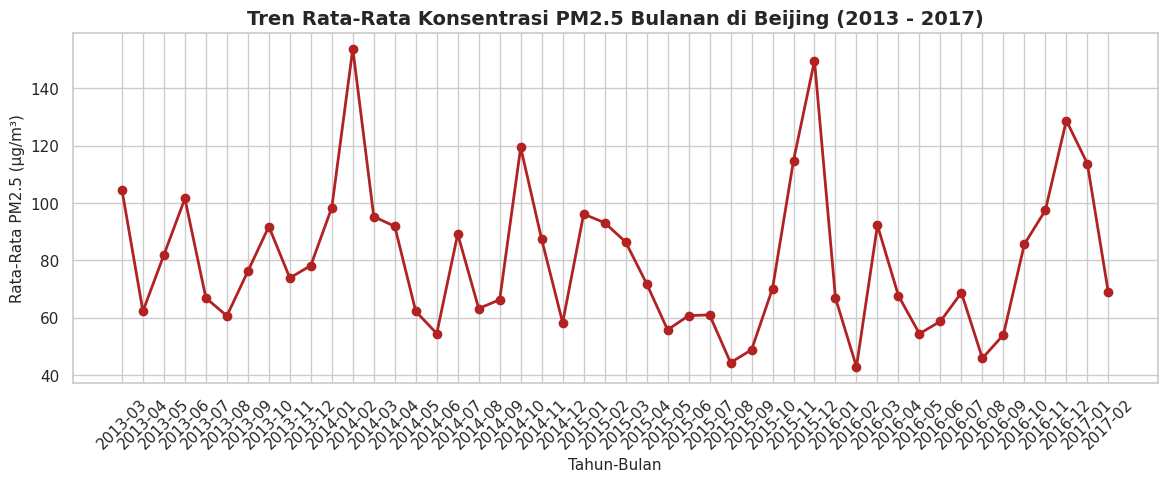

In [17]:
# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# Line Chart Tren PM2.5 Bulanan (Q1)
plt.subplot(2, 1, 1)
# Membuat variabel string gabungan YYYY-MM untuk sumbu X
monthly_df['year_month'] = monthly_df['year'].astype(str) + '-' + monthly_df['month'].astype(str).str.zfill(2)

plt.plot(monthly_df['year_month'], monthly_df['PM2.5'], marker='o', linewidth=2, color='firebrick')
plt.title('Tren Rata-Rata Konsentrasi PM2.5 Bulanan di Beijing (2013 - 2017)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun-Bulan', fontsize=11)
plt.ylabel('Rata-Rata PM2.5 (µg/m³)', fontsize=11)
plt.xticks(rotation=45)

plt.show()

**Insight**

Q1: *"Bagaimana tren konsentrasi rata-rata polutan `PM2.5` di seluruh stasiun kota Beijing secara bulanan sepanjang periode Maret 2013 hingga Februari 2017?"* (Tren Waktu)

Dari visualisasi diagram garis sebelumnya, terlihat rata-rata tingkat PM2.5 bulanan dari seluruh stasiun pemantauan udara di Beijing, dapat dilihat adanya pola musiman dari peningkatan dan penurunan PM2.5. Lonjakan tajam konsentrasi PM2.5 secara konsisten terjadi pada bulan-bulan musim dingin (Desember–Januari–Februari), seperti puncak pada Jan 2014 (\~150 $\mu\text{g/m}^3$) dan Des 2015 (\~148 $\mu\text{g/m}^3$).

Hal ini erat kaitannya dengan peningkatan pembakaran batubara untuk pemanas kota di Beijing selama musim dingin - musim semi.

Dari grafik juga bisa dilihat bahwa kadar PM2.5 menurun pada bulan-bulan musim panas - musim gugur, yakni pada bulan Mei-Agustus

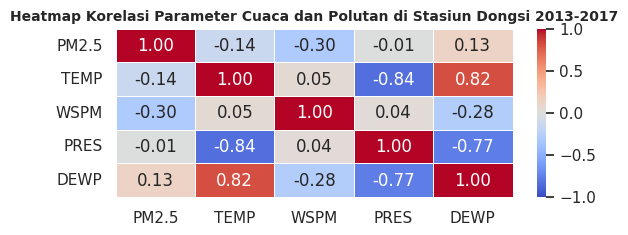

In [18]:
# Bar Chart Korelasi Faktor Cuaca terhadap PM2.5 di Stasiun Dongsi (Q2)
plt.subplot(2, 1, 2)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Parameter Cuaca dan Polutan di Stasiun Dongsi 2013-2017', fontsize=10, fontweight='bold')

plt.show()

**Insight**

Q2: *"Bagaimana hubungan/korelasi antara faktor cuaca (suhu `TEMP` dan kecepatan angin `WSPM`) terhadap tingkat konsentrasi `PM2.5` pada stasiun pemantau dengan tingkat polusi tertinggi secara bulanan sepanjang periode Maret 2013 - Februari 2017?"* (Korelasi Cuaca)

Dari visualisasi heatmap dari korelasi antara PM2.5 dan parameter cuaca yang ditangkap seluruh stasiun bulanan sepanjang Maret 2013 - Februari 2017 ditemukan beberapa fakta:

1. Variabel Kecepatan Angin (`WSPM`) memiliki korelasi negatif paling kuat terhadap PM2.5 (-0.30) sepanjang Maret 2013 - Februari 2017. Salah satu kesimpulan yang ditarik adalah angin kencang membantu menyebarkan (dispersi) polutan sehingga konsentrasi PM2.5 berkurang.

2. Variabel Suhu (`TEMP`) memiliki korelasi negatif (-0.14), sejalan dengan temuan bahwa suhu rendah (musim dingin) bertepatan dengan polusi yang lebih tinggi sepanjang Maret 2013 - Februari 2017. Pada musim dingin, polusi meningkat akibat meningkatnya pembakaran batu bara untuk tenaga listrik, sedang pada musim panas, udara membantu dispersi polutan dan hujan membilas polutan.

3. Variabel Titik Embun (`DEWP`) memiliki korelasi positif (0.13) sepanjang Maret 2013 - Februari 2017, di mana kelembapan/titik embun yang lebih tinggi sedikit memicu akumulasi partikel halus.

## Analisis Lanjutan: Manual Grouping / Binning (Kategori Kualitas Udara PM2.5)
* Tujuan Analisis:

Pada tahap ini dilakukan pengelompokan manual (Binning) untuk membagi tingkat konsentrasi PM2.5 ke dalam kategori kualitas udara (seperti Baik, Sedang, Tidak Sehat, dan Sangat Tidak Sehat) berdasarkan ambang batas kesehatan.

* Catatan Struktur Data:

Karena setiap baris data mewakili rekam observasi per jam di masing-masing stasiun sepanjang Maret 2013 - Februari 2017, hasil frekuensi dari analisis ini menggambarkan total akumulasi jam pengamatan di mana kondisi PM2.5 berada pada level tertentu. Hal ini bertujuan untuk mengukur seberapa sering warga kota Beijing terpapar kualitas udara pada level aman maupun berbahaya sepanjang periode pengamatan.

In [19]:
# Menentukan batas interval (bins) dan label kategori PM2.5 (Standar AQI Sederhana)
bins = [0, 35, 75, 150, 1000]
labels = ['Baik', 'Sedang', 'Tidak Sehat', 'Sangat Tidak Sehat']

# Membuat kolom baru 'pm25_category' menggunakan pd.cut
main_df['pm25_category'] = pd.cut(main_df['PM2.5'], bins=bins, labels=labels)

# Menampilkan distribusi frekuensi jumlah jam per kategori
category_counts = main_df['pm25_category'].value_counts()
print("--- Distribusi Frekuensi Kategori Kualitas Udara PM2.5 ---")
print(category_counts)

--- Distribusi Frekuensi Kategori Kualitas Udara PM2.5 ---
pm25_category
Baik                  156965
Tidak Sehat           100528
Sedang                 99415
Sangat Tidak Sehat     63860
Name: count, dtype: int64


**Insight**

Kategori Baik mencatatkan frekuensi tertinggi yaitu 156.965 jam, menunjukkan bahwa pada sebagian besar waktu, kualitas udara berada pada tingkat relatif aman.

Meskipun kondisi baik mendominasi, akumulasi frekuensi untuk kategori Tidak Sehat (100.528 jam) dan Sangat Tidak Sehat (63.860 jam) secara total mencapai 164.388 jam.

Dari kategorisasi ini terlihat bahwa warga kota Beijing terpapar udara dengan tingkat pencemaran PM2.5 di atas batas aman selama hampir 2/5 dari total rentang waktu pengamatan, sehingga diperlukan intervensi mitigasi polusi yang lebih intensif pada periode-periode kritis.

## Kesimpulan dan Rekomendasi

### Kesimpulan

Berdasarkan analisis, konsentrasi rata-rata polutan PM2.5 di kota Beijing dari kurun waktu Maret 2013 hingga Februari 2017 mengindikasikan pola fluktuasi musiman (*seasonal pattern*). Puncak polusi (*peak levels*) secara konsisten terjadi pada bulan-bulan musim dingin dan semi (Desember hingga Februari), memuncak pada Januari 2014 (\~150 $\mu\text{g/m}^3$) dan Desember 2015 (\~148 $\mu\text{g/m}^3$). Sebaliknya, konsentrasi PM2.5 berada pada titik terendah selama pertengahan tahun/musim panas - musim gugur (Mei hingga Agustus).

Melalui rekam data, dtiemukan bahwa Stasiun Dongsi merupakan stasiun yang mendeteksi rata-rata PM2.5 tertinggi yaitu 86,14 $\mu\text{g/m}^3$. Setelah dilakukan analisis, disimpulkan bahwa faktor kecepatan angin (`WSPM`) memiliki korelasi negatif sedang paling signifikan ($r = -0,30$) terhadap konsentrasi PM2.5. Hal ini menunjukkan kecepatan angin yang lebih tinggi efektif membantu menyebarkan (dispersi) polutan di udara. Sementara itu, suhu (`TEMP`) juga berkorelasi negatif ($r = -0,14$), mengonfirmasi bahwa suhu rendah saat musim dingin memperparah penumpukan partikel PM2.5.

Berdasarkan binning tingkat PM2.5 per jam pada dataset, kondisi udara kategori **Baik** mendominasi sebanyak 156.965 jam. Namun, kondisi udara tercemar yang tergolong **Tidak Sehat** hingga **Sangat Tidak Sehat** secara akumulatif mencapai 164.388 jam, yang membuktikan bahwa warga kota Beijing terpapar udara tercemar di atas batas aman selama hampir dua per lima dari total rentang waktu pengamatan.

### Rekomendasi

1. Pemerintah kota dan pemangku kepentingan perlu memperketat pembatasan aktivitas industri serta emisi pemanas berbasis batubara khusus pada kuartal keempat dan pertama (Desember–Februari) untuk menekan lonjakan polusi musim dingin.

2. Pemerintah perlu mengembangkan sistem peringatan dini kualitas udara bagi masyarakat di area Stasiun Dongsi yang mengintegrasikan prakiraan kecepatan angin. Ketika kondisi kecepatan angin diprediksi rendah pada musim dingin, imbauan penggunaan masker medis dan pengurangan aktivitas luar ruangan harus diterbitkan secara proaktif.

3. Mengingat akumulasi kondisi tidak sehat mencapai ~39,1% dari total waktu pengamatan, pemerintah daerah disarankan untuk menambah area ruang terbuka hijau serta memfasilitasi pemasangan filter udara medis di fasilitas-fasilitas publik.